# BERT Tokenization + VADER Sentiment for Reddit Comments

This notebook demonstrates how to use the BERT tokenizer for text processing and VADER for 3-class sentiment analysis (positive/negative/neutral) on Reddit comment data from the Sentimentrix project.

## Goals:

1. Load Reddit comments data

2. Tokenize text using BERT tokenizer

3. Apply VADER sentiment classification (3-class)

4. Visualize and analyze results

## Step 1: Import Required Libraries

Import the necessary libraries, including pandas, matplotlib, and the BERT tokenizer from Hugging Face.

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from transformers import BertTokenizer


## Step 2: Load Data

In [90]:
# Load Reddit comments data
D_westernu_comments = pd.read_csv("../../dataset/reddit_data/WesternU_comments.csv")
print(f"Total comments: {len(D_westernu_comments)}")
display(D_westernu_comments.head())

Total comments: 47


,post_id,comment_id,comment_text,comment_score,comment_author,comment_created_utc,parent_id,reply_to_id,comment_sentiment,has_images,num_images,image_urls,subreddit
0,12p2lmp,kvayuwc,Meee I’m probably doing health sci,1,[deleted],1.710695e+09,t3_12p2lmp,12p2lmp,NaN,False,0,NaN,WesternU
1,12p2lmp,jlprjaz,Hi,1,Purple_Character6184,1.685117e+09,t3_12p2lmp,12p2lmp,NaN,False,0,NaN,WesternU
2,12dvo59,lm2j9yu,"Congrats! May I know your stats, like gpa and ...",1,Only_Researcher6011,1.725773e+09,t3_12dvo59,12dvo59,NaN,False,0,NaN,WesternU
3,ztfu7e,lm9oi3b,I am interested in!,1,Only_Researcher6011,1.725886e+09,t3_ztfu7e,ztfu7e,NaN,False,0,NaN,WesternU
4,ztfu7e,m7hxd3l,yes,1,Eastern-State6466,1.737054e+09,t3_ztfu7e,ztfu7e,NaN,False,0,NaN,WesternU


## Step 3: Data Preprocessing

In [91]:
# Data preprocessing: remove empty/short comments, standardize column name
MIN_LEN = 2
text_col = None
for candidate in ['comment_text', 'body', 'text', 'commentBody']:
    if candidate in D_westernu_comments.columns:
        text_col = candidate
        break

if text_col is None:
    raise KeyError(f'No text column found in comments CSV. Columns: {D_westernu_comments.columns.tolist()}')

print('Using text column:', text_col)

D_comments_clean = D_westernu_comments.dropna(subset=[text_col]).copy()
D_comments_clean[text_col] = D_comments_clean[text_col].astype(str).str.strip()
D_comments_clean = D_comments_clean[D_comments_clean[text_col].str.len() >= MIN_LEN].copy()
D_comments_clean = D_comments_clean.rename(columns={text_col: 'comment_text'})

print(f"Original rows: {len(D_westernu_comments)}, after dropna and min length ({MIN_LEN}): {len(D_comments_clean)}")
display(D_comments_clean[['comment_id', 'comment_text']].head())

Using text column: comment_text
Original rows: 47, after dropna and min length (2): 47


,comment_id,comment_text
0,kvayuwc,Meee I’m probably doing health sci
1,jlprjaz,Hi
2,lm2j9yu,"Congrats! May I know your stats, like gpa and ..."
3,lm9oi3b,I am interested in!
4,m7hxd3l,yes


## Step 4: BERT Tokenization Example

In [92]:
# Initialize BERT tokenizer and show example tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
sample_text = D_comments_clean['comment_text'].iloc[0] if len(D_comments_clean) > 0 else "Example text"
tokens = tokenizer.tokenize(sample_text)
input_ids = tokenizer(sample_text, return_tensors="pt")["input_ids"]
print("Sample text:", sample_text)
print("BERT tokens:", tokens)
print("Token IDs:", input_ids)

Sample text: Meee I’m probably doing health sci
BERT tokens: ['me', '##ee', 'i', '’', 'm', 'probably', 'doing', 'health', 'sci']
Token IDs: tensor([[  101,  2033,  4402,  1045,  1521,  1049,  2763,  2725,  2740, 16596,
           102]])


## Step 4b: Extract BERT Embeddings for Comments
We use the BERT model to convert tokenized comments into contextual embeddings. These embeddings can be used for downstream NLP tasks.

In [93]:
from transformers import BertModel
import torch

# Load pre-trained BERT model (without classification head)
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()  # set to evaluation mode

# Example: get embeddings for the first comment
with torch.no_grad():
    inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=128)
    outputs = bert_model(**inputs)
    # outputs.last_hidden_state shape: (batch_size, sequence_length, hidden_size)
    # Use the [CLS] token embedding as a summary representation
    cls_embedding = outputs.last_hidden_state[0, 0, :].numpy()
print("[CLS] embedding shape:", cls_embedding.shape)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

[CLS] embedding shape: (768,)


In [ ]:
# Batch extract [CLS] embeddings for all comments (may take a while for large datasets)
from tqdm.notebook import tqdm
all_cls_embeddings = []
for text in tqdm(D_comments_clean['comment_text'].tolist(), desc='Extracting BERT embeddings'):
    with torch.no_grad():
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
        outputs = bert_model(**inputs)
        cls_emb = outputs.last_hidden_state[0, 0, :].numpy()
        all_cls_embeddings.append(cls_emb)
# Convert to numpy array and add to DataFrame
import numpy as np
bert_cls_matrix = np.stack(all_cls_embeddings)
print('BERT embedding matrix shape:', bert_cls_matrix.shape)
# Optionally, add as columns (not recommended for high-dim) or save separately

## Step 5: VADER Sentiment Analysis (3-class)

In [94]:
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# Compute VADER sentiment for each comment
D_comments_clean['sentiment_scores'] = D_comments_clean['comment_text'].apply(lambda x: analyzer.polarity_scores(x) if isinstance(x, str) else {'compound': 0.0})
D_comments_clean['compound'] = D_comments_clean['sentiment_scores'].apply(lambda x: x['compound'])

def get_sentiment_label(comp):
    if comp >= 0.05: return 'positive'
    if comp <= -0.05: return 'negative'
    return 'neutral'

D_comments_clean['comment_sentiment'] = D_comments_clean['compound'].apply(get_sentiment_label)

print(D_comments_clean['comment_sentiment'].value_counts())

comment_sentiment
neutral     21
positive    21
negative     5
Name: count, dtype: int64


## Step 6: Results and Visualization

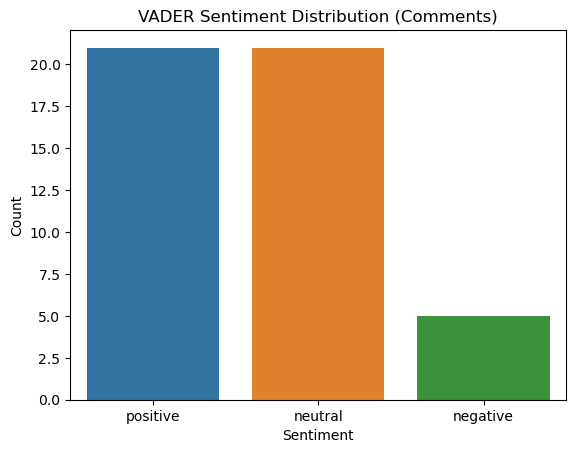

In [95]:
# Visualize VADER sentiment distribution
sns.countplot(data=D_comments_clean, x='comment_sentiment', order=['positive','neutral','negative'])
plt.title('VADER Sentiment Distribution (Comments)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()